<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Multivariate_Occupancy_Lags.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 8 — Multivariate window method: room occupancy
- Still the window method, now with covariates: HVAC sensors (temperature, humidity, light, CO2) -> is the room occupied?
- Mostly unoccupied (imbalance); plot the target with CO2 and the story tells itself.
- Lag features from the past few minutes - and DROP lagged occupancy to avoid leakage (20 columns).
- 50/50 unshuffled split, sigmoid head -> ~97% and a mostly-diagonal confusion matrix.
-->


# Multivariate Occupancy Example (Lags/Window Method)
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Let's see if we can predict if it's a room is occupied as a function of environmental data.

Link: http://archive.ics.uci.edu/ml/datasets/Occupancy+Detection+

Same flow as before, just need to prep our data differently. For now, we ignore the time dimension but we could resample to a regular resolution.

Wow - also a nice example: https://machinelearningmastery.com/multivariate-time-series-forecasting-lstms-keras/

In [1]:
# standard modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# RNN-specific modules
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report,accuracy_score
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, GRU, LSTM
from tensorflow.keras.callbacks import EarlyStopping

# reproducibility: same seed every run (numbers on CPU match exactly; a GPU may drift a little)
import keras
keras.utils.set_random_seed(5509)


## Read in data
Check for missing values, make some plots.

In [2]:
# Dataset: UCI room-occupancy detection (Candanedo & Feldheim, 2016), originally from LuisM78's GitHub.
# We use the two real files - 8,143 minutes of training data (Feb 4-10) followed by 9,752 of test (Feb 11-18) -
# stacked in date order into one two-week series. (The 2-day datatest.txt slice was too short to learn from.)
base = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/"
df = pd.concat([pd.read_csv(base + "datatraining.txt"), pd.read_csv(base + "datatest2.txt")], ignore_index=True)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)   # chronological - never shuffle a time series
print(df.info())
df.head(n=15) # nice complete data! this will allow us to check our work later

<class 'pandas.DataFrame'>
RangeIndex: 17895 entries, 0 to 17894
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           17895 non-null  datetime64[us]
 1   Temperature    17895 non-null  float64       
 2   Humidity       17895 non-null  float64       
 3   Light          17895 non-null  float64       
 4   CO2            17895 non-null  float64       
 5   HumidityRatio  17895 non-null  float64       
 6   Occupancy      17895 non-null  int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 978.8 KB
None


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,2015-02-04 17:51:00,23.180,27.272000,426.0,721.250000,0.004793,1
1,2015-02-04 17:51:59,23.150,27.267500,429.5,714.000000,0.004783,1
2,2015-02-04 17:53:00,23.150,27.245000,426.0,713.500000,0.004779,1
3,2015-02-04 17:54:00,23.150,27.200000,426.0,708.250000,0.004772,1
4,2015-02-04 17:55:00,23.100,27.200000,426.0,704.500000,0.004757,1
5,2015-02-04 17:55:59,23.100,27.200000,419.0,701.000000,0.004757,1
6,2015-02-04 17:57:00,23.100,27.200000,419.0,701.666667,0.004757,1
7,2015-02-04 17:57:59,23.100,27.200000,419.0,699.000000,0.004757,1
8,2015-02-04 17:58:59,23.100,27.200000,419.0,689.333333,0.004757,1
9,2015-02-04 18:00:00,23.075,27.175000,419.0,688.000000,0.004745,1


In [3]:
# count of occupancy
df['Occupancy'].value_counts() # not perfectly balanced, but that's OK

Occupancy
0    14117
1     3778
Name: count, dtype: int64

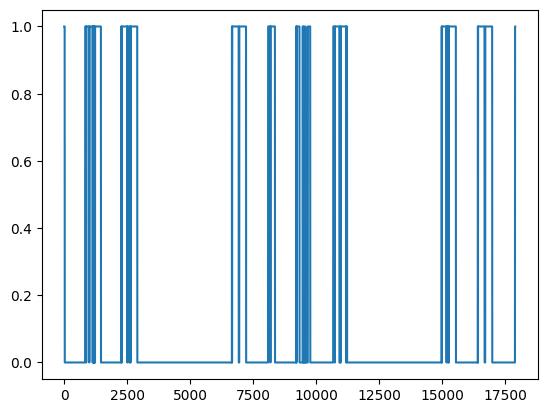

In [4]:
# visualize the data
df['Occupancy'].plot()
plt.show()

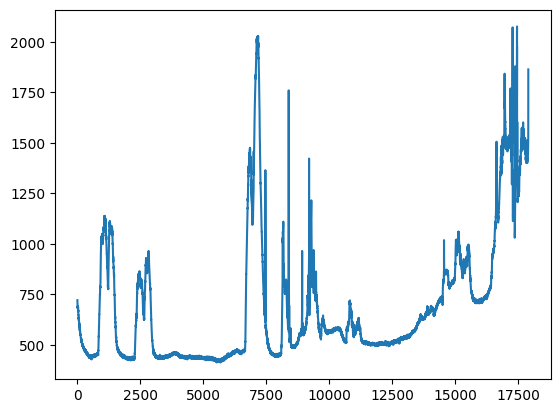

In [5]:
# visualize the data
df['CO2'].plot()
plt.show()

In [6]:
# drop the date column
df.drop(['date'], inplace=True, axis=1)
print(df.shape)
df.head()

(17895, 6)


,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,23.18,27.2720,426.0,721.25,0.004793,1
1,23.15,27.2675,429.5,714.00,0.004783,1
2,23.15,27.2450,426.0,713.50,0.004779,1
3,23.15,27.2000,426.0,708.25,0.004772,1
4,23.10,27.2000,426.0,704.50,0.004757,1


<!-- WINDOW-FN -->
## The window-making function: `series_to_supervised`

Turns a table of time-ordered rows into a table a model can learn from, by lining up shifted copies side by side.

- **`lookback`**: how many **past** rows become input columns (`var(t-lookback)` … `var(t-1)`).
- **`horizon`**: how many rows, **starting now**, become target columns (`var(t)`, `var(t+1)`, …). `horizon=1` means just now.
- **`dropnan`**: drops the edge rows that don't have a full history.

With several columns, **every column gets its own lags**: `var1` … `var5` are the five sensors and `var6` is occupancy. That's why we drop the lagged occupancy columns next (using them would leak the answer).


In [7]:
# link: https://machinelearningmastery.com/convert-time-series-supervised-learning-problem-python/

# we will probably drop the Y variable before running this

from pandas import DataFrame
from pandas import concat

def series_to_supervised(data, lookback=1, horizon=1, dropnan=True):
	"""
	Frame a time series as a supervised learning dataset.
	Arguments:
		data: Sequence of observations as a list or NumPy array.
		lookback: how many PAST rows become input columns (X) - the lags t-1, t-2, ...
		horizon: how many rows, starting NOW, become target columns (y) - 1 means just t
		dropnan: Boolean whether or not to drop rows with NaN values.
	Returns:
		Pandas DataFrame of series framed for supervised learning.
	"""
	n_vars = 1 if type(data) is list else data.shape[1]
	df = DataFrame(data)
	cols, names = list(), list()
	# input sequence (t-n, ... t-1)
	for i in range(lookback, 0, -1):
		cols.append(df.shift(i))
		names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
	# forecast sequence (t, t+1, ... t+n)
	for i in range(0, horizon):
		cols.append(df.shift(-i))
		if i == 0:
			names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
		else:
			names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
	# put it all together
	agg = concat(cols, axis=1)
	agg.columns = names
	# drop rows with NaN values
	if dropnan:
		agg.dropna(inplace=True)
	return agg

In [8]:
# now let's prep the data - just processing X
tmp = series_to_supervised(df, lookback=3, horizon=1)

We can do some clean-up here and get rid of the y columns we don't need (unless we want to use prior timesteps!) It's your choice - do you want to use past values of y to make a prediction - or just use the X variables?

In [9]:
print(tmp.info())
tmp.head()

<class 'pandas.DataFrame'>
RangeIndex: 17892 entries, 3 to 17894
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   var1(t-3)  17892 non-null  float64
 1   var2(t-3)  17892 non-null  float64
 2   var3(t-3)  17892 non-null  float64
 3   var4(t-3)  17892 non-null  float64
 4   var5(t-3)  17892 non-null  float64
 5   var6(t-3)  17892 non-null  float64
 6   var1(t-2)  17892 non-null  float64
 7   var2(t-2)  17892 non-null  float64
 8   var3(t-2)  17892 non-null  float64
 9   var4(t-2)  17892 non-null  float64
 10  var5(t-2)  17892 non-null  float64
 11  var6(t-2)  17892 non-null  float64
 12  var1(t-1)  17892 non-null  float64
 13  var2(t-1)  17892 non-null  float64
 14  var3(t-1)  17892 non-null  float64
 15  var4(t-1)  17892 non-null  float64
 16  var5(t-1)  17892 non-null  float64
 17  var6(t-1)  17892 non-null  float64
 18  var1(t)    17892 non-null  float64
 19  var2(t)    17892 non-null  float64
 20  var3(t)    17892 

,var1(t-3),var2(t-3),var3(t-3),var4(t-3),var5(t-3),var6(t-3),var1(t-2),var2(t-2),var3(t-2),var4(t-2),...,var3(t-1),var4(t-1),var5(t-1),var6(t-1),var1(t),var2(t),var3(t),var4(t),var5(t),var6(t)
3,23.18,27.2720,426.0,721.25,0.004793,1.0,23.15,27.2675,429.5,714.00,...,426.0,713.500000,0.004779,1.0,23.15,27.2,426.0,708.250000,0.004772,1
4,23.15,27.2675,429.5,714.00,0.004783,1.0,23.15,27.2450,426.0,713.50,...,426.0,708.250000,0.004772,1.0,23.10,27.2,426.0,704.500000,0.004757,1
5,23.15,27.2450,426.0,713.50,0.004779,1.0,23.15,27.2000,426.0,708.25,...,426.0,704.500000,0.004757,1.0,23.10,27.2,419.0,701.000000,0.004757,1
6,23.15,27.2000,426.0,708.25,0.004772,1.0,23.10,27.2000,426.0,704.50,...,419.0,701.000000,0.004757,1.0,23.10,27.2,419.0,701.666667,0.004757,1
7,23.10,27.2000,426.0,704.50,0.004757,1.0,23.10,27.2000,419.0,701.00,...,419.0,701.666667,0.004757,1.0,23.10,27.2,419.0,699.000000,0.004757,1


In [10]:
# here are X and y
y = tmp['var6(t)']
X = tmp.drop(['var6(t)'], axis=1)
print(X.shape, y.shape)

(17892, 23) (17892,)


In [11]:
# for fun, you can delete previous occupancy
del X['var6(t-1)']
del X['var6(t-2)']
del X['var6(t-3)']
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 17892 entries, 3 to 17894
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   var1(t-3)  17892 non-null  float64
 1   var2(t-3)  17892 non-null  float64
 2   var3(t-3)  17892 non-null  float64
 3   var4(t-3)  17892 non-null  float64
 4   var5(t-3)  17892 non-null  float64
 5   var1(t-2)  17892 non-null  float64
 6   var2(t-2)  17892 non-null  float64
 7   var3(t-2)  17892 non-null  float64
 8   var4(t-2)  17892 non-null  float64
 9   var5(t-2)  17892 non-null  float64
 10  var1(t-1)  17892 non-null  float64
 11  var2(t-1)  17892 non-null  float64
 12  var3(t-1)  17892 non-null  float64
 13  var4(t-1)  17892 non-null  float64
 14  var5(t-1)  17892 non-null  float64
 15  var1(t)    17892 non-null  float64
 16  var2(t)    17892 non-null  float64
 17  var3(t)    17892 non-null  float64
 18  var4(t)    17892 non-null  float64
 19  var5(t)    17892 non-null  float64
dtypes: float64(20)
me

In [12]:
# take a peak at what it did
print(X.shape) # see how X has blown up?
print(y.shape)

# scroll up and make sure you understand this!
# y is a function of X (the previous n_steps observations!)

(17892, 20)
(17892,)


In [13]:
# split the data into train and test partitions
# we will use 50% of the data for train, and 50% for validation
train_pct_index = int(0.5 * len(X))
X_train, X_test = X[:train_pct_index], X[train_pct_index:]
y_train, y_test = y[:train_pct_index], y[train_pct_index:]

# pretty slick way of splitting your data using slicing!
# notice how we didn't do any shuffling (we don't want temporal leakage! keeps time series intact)

In [14]:
# check the shape to be sure
print(X.shape, X_train.shape, X_test.shape)
print(y.shape, y_train.shape, y_test.shape)

# verify that this all adds up!

(17892, 20) (8946, 20) (8946, 20)
(17892,) (8946,) (8946,)


## One helper to score every model

Every model below gets the same treatment, so they are comparable: **train and test**, the F1 for each, the test
confusion matrix, and two pictures.

The important choice here is that we plot **`model.predict()` directly - the probability - and never the rounded
class**. Rounding to 0/1 throws away the only interesting part, which is *how sure the model was*. A model that
says 0.51 and a model that says 0.99 both round to "occupied", and you want to be able to tell them apart.

In [15]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score

scores = {}

def show_results(name, model):
    """Train and test for a classifier - and we plot the PROBABILITY the model reports, never the rounded class.
    Rounding throws away the only interesting part: how SURE the model was.

    Left  : P(occupied) over time, with the true occupancy shaded behind it and the 0.5 threshold dashed.
    Right : the separation plot - P(occupied) histogrammed by true class. A good classifier puts two tall piles
            at 0 and 1 with an empty middle; a hesitant one fills the middle."""
    p_tr = model.predict(X_train, verbose=0).ravel()
    p_te = model.predict(X_test,  verbose=0).ravel()
    f1_tr = f1_score(y_train, (p_tr >= 0.5).astype(int), average="weighted")
    f1_te = f1_score(y_test,  (p_te >= 0.5).astype(int), average="weighted")
    scores[name] = f1_te
    print(f"{name}:  train F1 = {f1_tr:.3f}   test F1 = {f1_te:.3f}   (gap {f1_te - f1_tr:+.3f})")
    print("\nconfusion matrix (test):")
    print(confusion_matrix(y_test, (p_te >= 0.5).astype(int)))
    print(classification_report(y_test, (p_te >= 0.5).astype(int), digits=3))

    WIN = 1500                      # 9,000 minutes at once is an unreadable barcode - show a window of it
    fig, ax = plt.subplots(2, 2, figsize=(13, 6), gridspec_kw={"width_ratios": [2.4, 1]})
    for r, (split, y_true, p) in enumerate([("train", y_train, p_tr), ("test", y_test, p_te)]):
        start = int(np.argmax(np.abs(np.diff(y_true)) > 0))          # start at the first change of state
        sl = slice(start, start + WIN)
        t = np.arange(len(y_true))[sl]
        ax[r][0].fill_between(t, 0, y_true[sl], step="mid", color="#C8E6C9", label="actually occupied")
        ax[r][0].plot(t, p[sl], color="#C62828", lw=1.0, label="P(occupied)")
        ax[r][0].axhline(0.5, color="#616161", ls="--", lw=0.8)
        ax[r][0].set_ylim(-0.05, 1.05); ax[r][0].set_ylabel("P(occupied)")
        ax[r][0].set_title(f"{name} - {split} (a {WIN}-step window)"); ax[r][0].legend(loc="center left", fontsize=8)
        bins = np.linspace(0, 1, 31)
        ax[r][1].hist(p[y_true == 0], bins=bins, color="#1565C0", alpha=0.75, label="was empty")
        ax[r][1].hist(p[y_true == 1], bins=bins, color="#EF6C00", alpha=0.75, label="was occupied")
        ax[r][1].axvline(0.5, color="#616161", ls="--", lw=1.0)
        ax[r][1].set_yscale("log"); ax[r][1].set_xlim(0, 1)
        ax[r][1].set_xlabel("P(occupied)  ->  the model's confidence")
        ax[r][1].set_ylabel("number of windows (log)")
        ax[r][1].set_title("was it confident, and was it right?", fontsize=10)
        ax[r][1].text(0.02, 0.97, "model says EMPTY", transform=ax[r][1].transAxes,
                      fontsize=7.5, va="top", ha="left", color="#1565C0")
        ax[r][1].text(0.98, 0.97, "model says OCCUPIED", transform=ax[r][1].transAxes,
                      fontsize=7.5, va="top", ha="right", color="#EF6C00")
        ax[r][1].legend(fontsize=8, loc="upper center")
    ax[1][0].set_xlabel("time step (minute)")
    plt.tight_layout(); plt.show()

### How to read the right-hand plot

The left plot is the story over time. The right one is a **separation plot**, and it answers a different question:
*when the model committed to an answer, how sure was it, and was it right?*

Every test window is dropped into a bucket by the probability the model gave it, then coloured by what actually
happened - **blue = the room was empty, orange = the room was occupied**. The dashed line at 0.5 is where the
decision flips.

So there are four regions, and only two of them are good:

| where a bar sits | what it means |
| :-- | :-- |
| **blue, far left** | said "empty", and it was empty - confident and correct |
| **orange, far right** | said "occupied", and it was occupied - confident and correct |
| **orange, left of 0.5** | said "empty", but the room was occupied - **a confident mistake** |
| **blue, right of 0.5** | said "occupied", but the room was empty - **a confident mistake** |

What you want is **two tall piles at the ends and almost nothing in the middle**: the model is decisive and it is
right. Bars piling up near 0.5 mean a model that is hedging. Bars on the *wrong* side are the errors you already
counted in the confusion matrix - this just shows you how badly it was fooled.

The y-axis is on a log scale because the correct piles are thousands of windows tall and the mistakes are a
handful; on a linear axis the mistakes would be invisible.

In [16]:
# if we wanted to, we could do some scaling/normalization here, would not hurt!
# link: https://datascience.stackexchange.com/questions/12321/whats-the-difference-between-fit-and-fit-transform-in-scikit-learn-models

# do we need to fit this twice?!

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)
scaler.transform(X_train)
scaler.transform(X_test)

array([[-0.05922046, -0.25400435, -0.61321124, ..., -0.61269376,
        -0.13930594, -0.22977043],
       [-0.05922046, -0.3201862 , -0.61321124, ..., -0.61269376,
        -0.12942762, -0.33785018],
       [-0.05922046, -0.28196851, -0.61321124, ..., -0.61269376,
        -0.12448846, -0.33694965],
       ...,
       [ 0.15755558,  0.27125575,  1.60307963, ...,  1.56707559,
         3.01187673,  0.39229541],
       [ 0.15755558,  0.32718407,  1.59793444, ...,  1.54262717,
         3.37572802,  0.44327868],
       [ 0.20796861,  0.33231083,  1.565777  , ...,  1.49244358,
         4.13965109,  0.49256419]], shape=(8946, 20))

# DNN one layer model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           630 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 661 (2.58 KB)

 Trainable params: 661 (2.58 KB)

 Non-trainable params: 0 (0.00 B)

...

 68/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9710 - loss: 0.1469

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9678 - loss: 0.1609

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9693 - loss: 0.1532 - val_acc: 0.8793 - val_loss: 0.3235


Epoch 11: early stopping


Restoring model weights from the end of the best epoch: 1.


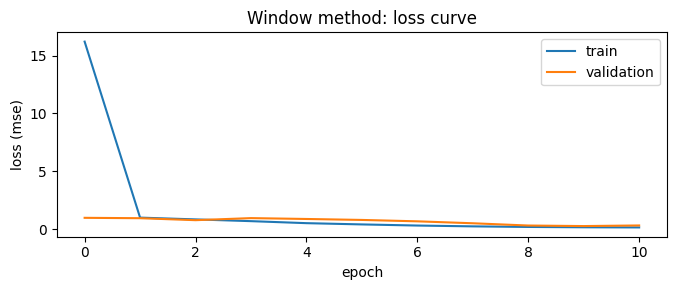

stopped after 11 epochs; best validation loss 0.271


In [17]:
# now let's build a model

# define model
model = Sequential()
model.add(Input(shape=(X.shape[1],)))
model.add(Dense(30, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['acc'])
model.summary()

es = EarlyStopping(monitor='val_acc', mode='max',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)


# fit model (uses early stopping)
history = model.fit(X_train, y_train,
          epochs=500,
          batch_size=64,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=1,
          callbacks=[es],
          shuffle=True)

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(history.history["loss"], label="train")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch"); plt.ylabel("loss (mse)"); plt.title("Window method: loss curve")
plt.legend(); plt.tight_layout(); plt.show()

print(f"stopped after {len(history.history['loss'])} epochs;"
      f" best validation loss {min(history.history['val_loss']):.3f}")

window method (dense net on the lag table):  train F1 = 0.919   test F1 = 0.943   (gap +0.024)

confusion matrix (test):
[[6920  191]
 [ 315 1520]]
              precision    recall  f1-score   support

           0      0.956     0.973     0.965      7111
           1      0.888     0.828     0.857      1835

    accuracy                          0.943      8946
   macro avg      0.922     0.901     0.911      8946
weighted avg      0.942     0.943     0.943      8946



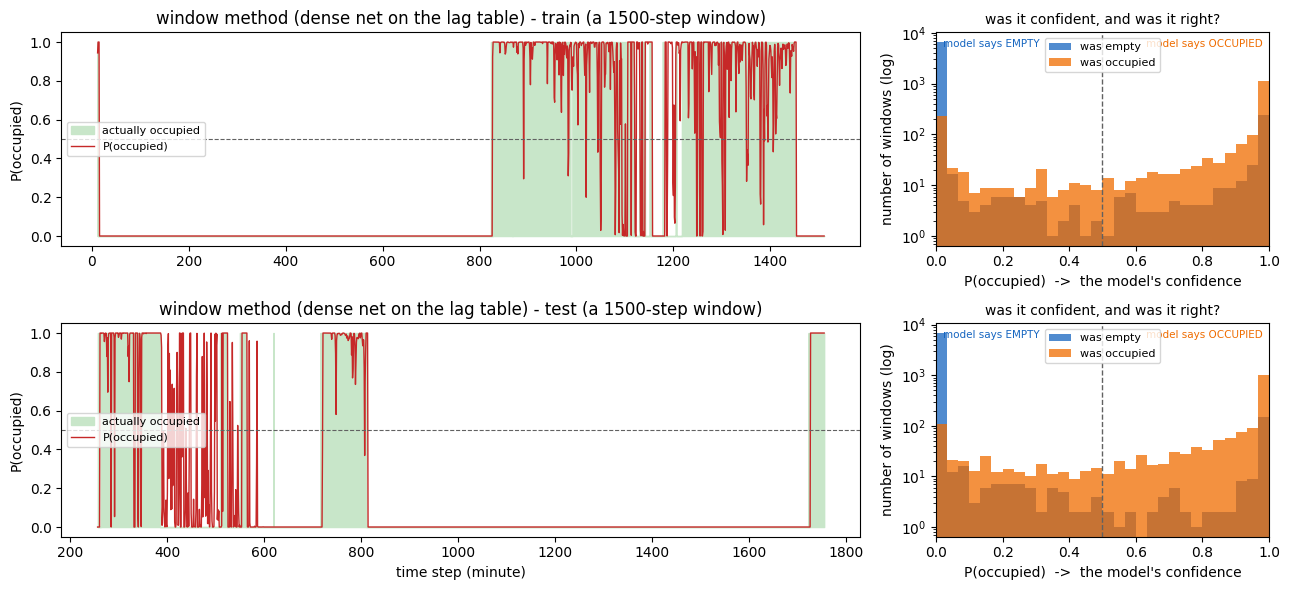

In [18]:
show_results("window method (dense net on the lag table)", model)

## Save the model and use it again

Reproducibility means more than a seed: **save the fitted model** so you (or a teammate, or your future self) can reload it and predict without retraining. Keras 3 saves to a single `.keras` file. The reloaded model must give *identical* predictions - we check.

In [19]:
from keras.models import load_model

model.save('Multivariate_Occupancy_Lags.keras')                 # one file: architecture + weights + optimizer state
reloaded = load_model('Multivariate_Occupancy_Lags.keras')

# same inputs, same answers?
import numpy as np
same = np.allclose(model.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0))
print('reloaded model reproduces the predictions:', same)
reloaded.summary()

reloaded model reproduces the predictions: True


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           630 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,985 (7.76 KB)

 Trainable params: 661 (2.58 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,324 (5.18 KB)

Think about what a baseline model would be... is it possible to predict occupancy without previous Y data (just use X?) To do this, you would just need to delete some of the variables in tmp before splitting, then re-run the model.